# Imports


In [168]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn import linear_model
from scipy.stats import norm

# Exercise 1
## Loading and computing
**Q1.**

In [169]:
data1 = pd.read_csv('./datasets/data1.csv', header=None, names=['X', 'y'])
data1.head()

,X,y
0,0.000000,-2.533067
1,0.204082,1.858307
2,0.408163,5.127848
3,0.612245,-1.779907
4,0.816327,1.192152


In [170]:
X_original = data1["X"].to_numpy().reshape(-1,1)
X_biased = np.hstack([np.ones((X_original.shape[0], 1)), X_original])
X= X_biased
y = data1["y"].to_numpy()
xTx= np.dot(X.T, X)
theta_hat = np.dot(np.linalg.inv(xTx), np.dot(X.T, y))


lin_reg = linear_model.LinearRegression(fit_intercept=False)
lin_reg.fit(X, y)
coeffs = lin_reg.coef_

print(theta_hat)
print(coeffs)
print(f"Is both results the same ? Answer : {np.allclose(theta_hat,coeffs)}")



[0.3230647  1.92916413]
[0.3230647  1.92916413]
Is both results the same ? Answer : True


**Q.2** For the number of bootstraps, it seems to have good results between 5000 and 10000 but the more you increase the number, the slower the algorithm gets. So 10000 seems a good maximum value for n_bootstrap.

In [ ]:
n_boot = 1000
n = len(y)
boot_coefs = np.zeros((n_boot, X.shape[1]))
alpha = 5

rng = np.random.default_rng(seed=42) 

for i in range(n_boot):
    idx = rng.integers(0, n, n)  
    X_boot = X[idx]
    y_boot = y[idx]
    
    xTx_boot = np.dot(X_boot.T, X_boot)
    theta_boot = np.dot(np.linalg.inv(xTx_boot), np.dot(X_boot.T, y_boot))
    boot_coefs[i, :] = theta_boot


lower = np.percentile(boot_coefs, 2.5, axis=0)[1]
upper = np.percentile(boot_coefs, 97.5, axis=0)[1]
print(f"CI pour { 100-alpha}% de la pente : [{lower}, {upper}]")


CI pour 95% de la pente : [1.711101899780172, 2.1291142246293373]


(50, 2)
(50,)


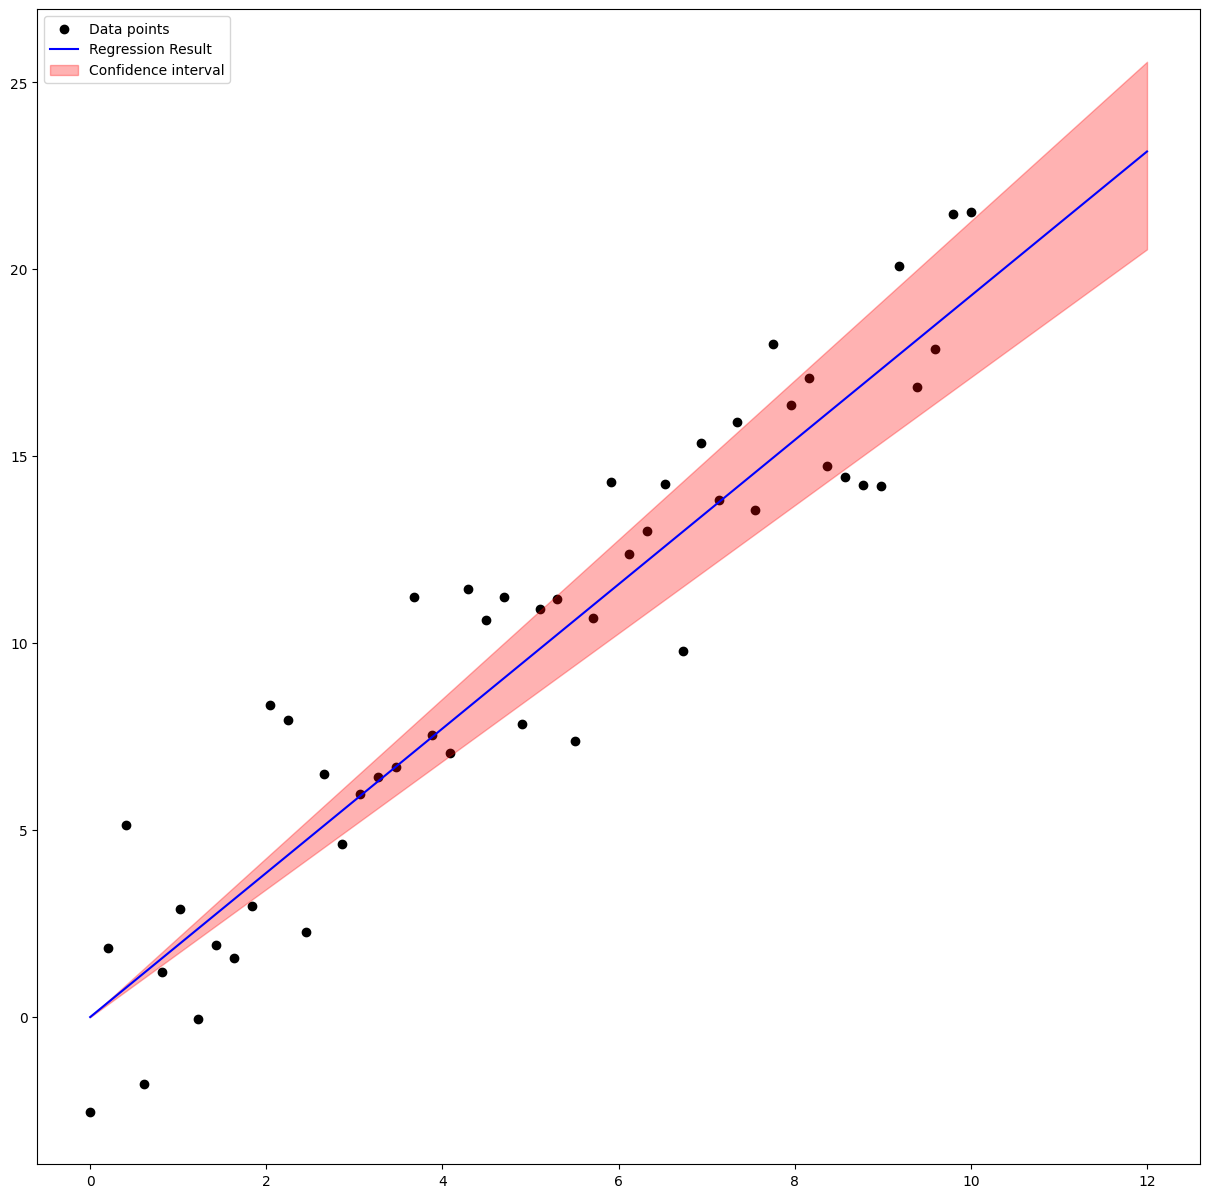

In [172]:
abs = np.linspace(0, 12, 120)
y_reg = coeffs[1]*abs

y_boot_low= abs * lower 
y_boot_up= abs*upper
print(X.shape)
print(y.shape)
plt.figure(figsize=(15,15))
plt.scatter(X_original, y, marker="o", c="black")
plt.plot(abs, y_reg, c='blue')
plt.fill_between(abs, y_boot_low, y_boot_up, color='red', alpha = 0.3)
plt.legend(['Data points', 'Regression Result', 'Confidence interval'])
plt.show()


## About the bootstramp samples
**Q4.** For the bootstrap method, the sampling is with replacement, so some observations are left out, this is the out-of-bag samples.
We can use it in the context of cross-validation by training on the bootstrap sample and testing on the out-of-bag samples and in the end report the results to determine which model is the best.

**Q5** For the case of the sampling, since it is uniform : 
$$\mathbb{P}((x_j, y_j) \text{ not selected}))=1-\frac{1}{n}$$
and for the n draws, since it is with replacement, it garantees the indenpencies of the random values :
$$\mathbb{P}\left((x_j, y_j) \notin B_i\right) = \left(1 - \frac{1}{n}\right)^n
$$
So :
$$\mathbb{P}\left((x_j, y_j) \in B_i\right) = 1 - \left(1 - \frac{1}{n}\right)^n \underset{n \rightarrow +\infty}{\rightarrow} 1-e^{-1}
$$

**Q.6**

In [173]:
diff_elements = []
for _ in range(n_boot):
    sample = np.random.choice(n, size=n, replace=True)
    uniques = len(np.unique(sample))
    diff_elements.append(uniques)

average_diff_el = np.mean(diff_elements)
print(average_diff_el/n)

0.63376


We get $\approx 0.635$ which is approximatively $1-e^{-1}$

## Analysis of results

**Q.7.** the C.I is [1.71, 2.12] so $\theta_1 = 2 \in$ C.I

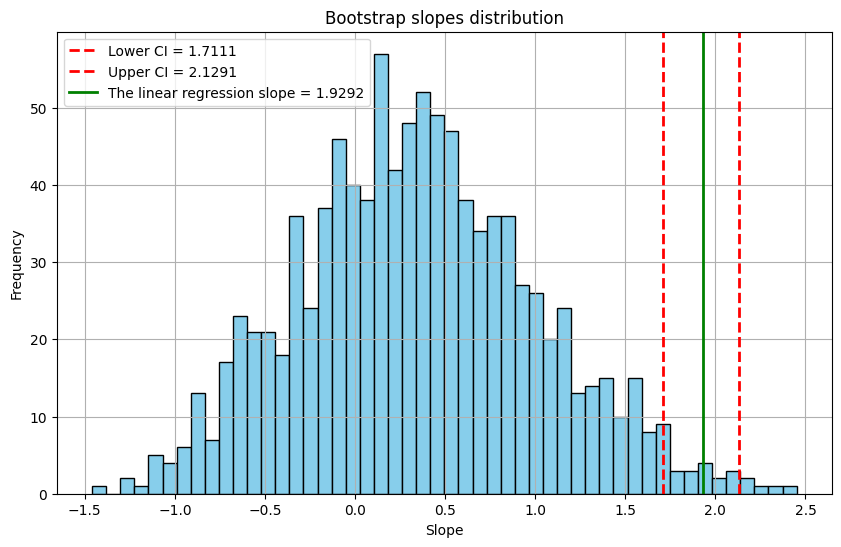

In [174]:
import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(10, 6))

plt.hist(boot_coefs[:,0], bins=50, color='skyblue', edgecolor='black')
plt.axvline(lower, color='red', linestyle='--', linewidth=2, label=f'Lower CI = {lower:.4f}')
plt.axvline(upper, color='red', linestyle='--', linewidth=2, label=f'Upper CI = {upper:.4f}')
plt.axvline(coeffs[1], color='green', linestyle='-', linewidth=2, label=f'The linear regression slope = {coeffs[1]:.4f}')


plt.title("Bootstrap slopes distribution")
plt.xlabel("Slope")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

**Q8.** the asymptotic C.I is the C.I when $n \rightarrow +\infty$. In this case, the distribution is normal so according to the course, it would be :
$$\left[ \hat {\theta }-Q(1-\alpha/2)\cdot \frac{\sigma}{\sqrt{n}},\  \hat {\theta }+Q(1-\alpha/2)\cdot \frac{\sigma}{\sqrt{n}}\right]$$



In [175]:
theta_pred=  coeffs[1]

q = norm.ppf(1-alpha/200)
sigma = np.std(boot_coefs[:,0])

lower_as = theta_pred - q*sigma/np.sqrt(n)
upper_as = theta_pred + q*sigma/np.sqrt(n)
print(f"The asymptotic confidence interval will be : [{lower_as}, {upper_as}]")

The asymptotic confidence interval will be : [1.7460290827193345, 2.1122991863937655]


We have Asymptotic C.I = [1.74, 2.11] so $\theta_1 = 2 \in$ Asymptotic C.I

# Exercise 2
**Q9.**

In [ ]:
names = ["X"+str(i) for i in range(1,101)]
names.append("y")
data2 = pd.read_csv("./datasets/data2.csv", header = None, names=names)

data2.head()


['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28', 'X29', 'X30', 'X31', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37', 'X38', 'X39', 'X40', 'X41', 'X42', 'X43', 'X44', 'X45', 'X46', 'X47', 'X48', 'X49', 'X50', 'X51', 'X52', 'X53', 'X54', 'X55', 'X56', 'X57', 'X58', 'X59', 'X60', 'X61', 'X62', 'X63', 'X64', 'X65', 'X66', 'X67', 'X68', 'X69', 'X70', 'X71', 'X72', 'X73', 'X74', 'X75', 'X76', 'X77', 'X78', 'X79', 'X80', 'X81', 'X82', 'X83', 'X84', 'X85', 'X86', 'X87', 'X88', 'X89', 'X90', 'X91', 'X92', 'X93', 'X94', 'X95', 'X96', 'X97', 'X98', 'X99', 'X100', 'y']


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X92,X93,X94,X95,X96,X97,X98,X99,X100,y
0,-0.208298,0.793446,-0.200865,-0.005766,-0.336092,0.037238,0.148319,-1.423624,-0.411594,0.541975,...,-0.216825,0.552672,0.499400,0.134669,-1.639742,-0.004640,-0.635006,-0.758949,0.488324,24.0
1,-0.221028,-0.363311,-0.631604,1.152664,-0.532182,1.176513,-0.100142,1.170051,0.360931,0.593115,...,0.571930,-0.186832,-0.238081,1.404931,0.489104,0.248675,0.361039,0.435418,-1.324025,21.6
2,-1.059124,-0.777557,-0.172609,0.767116,0.141027,0.677921,0.820292,-0.255193,0.691621,0.254366,...,-0.643929,-0.543850,-0.478493,-0.386637,0.175114,-0.658092,-0.338583,-0.177981,-0.050339,34.7
3,1.133450,-0.790638,-0.586627,0.942378,0.283674,-0.577118,-0.145977,-0.263209,1.435926,-0.750034,...,0.719154,0.056236,-0.495367,0.204324,-1.078683,0.640999,-0.921276,-0.602238,0.421393,33.4
4,0.908181,-0.913293,0.362265,-0.437131,0.514517,-1.625222,1.019997,-0.422887,0.140903,-0.073760,...,1.026587,-0.230706,0.151710,-0.638937,0.072631,-0.517829,-1.028707,0.465484,0.351005,36.2


In [ ]:
X = data2[names[:-1]].to_numpy()
y = data2[names[-1]].to_numpy()

V = y
not_selected = list(range(X.shape[1]))
selected_idx = []
p_vals = []
while not_selected:
    theta_ks=  []
    for column in not_selected:
        X_k = X[:,column]
        theta_k =np.dot(X_k,V)/np.linalg.norm(X_k) # Statistic Test
        theta_ks.append(theta_k)
    sigma = np.std(theta_ks)
    theta_m = np.mean(theta_ks)
    if sigma:
        p_val_thresh = theta_m/sigma
    else: p_val_thresh=-float("inf")
    p_val = 2*np.sum((np.array(theta_ks)>p_val_thresh).astype(int))/len(theta_ks) # p-value
    p_vals.append(p_val)
    best_idx = np.argmax(theta_ks)
    best_column = not_selected[best_idx]
    selected_idx.append(best_column)
    V = X[:, best_column]
    not_selected.remove(best_column)



**Q10.** The hypothesis testing would be :
$\mathcal{H}_0=\{\theta_k=0\}$, $\mathcal{H}_1=\{\theta_k\neq0\}$

In order to test, we choose the bigger $theta_k$ not selected and say that it is in the alternative hypothesis. So we select it and go to the next iteration

- The statistic is : $\theta _k=\frac{X_k^{\top }V}{\| X_k\| }$
- p-value = $\mathbb{P}(|\theta_k|>T)= 2 \mathbb{P}(theta_k>T)$ with T a threshold

**Q11.**

0.1


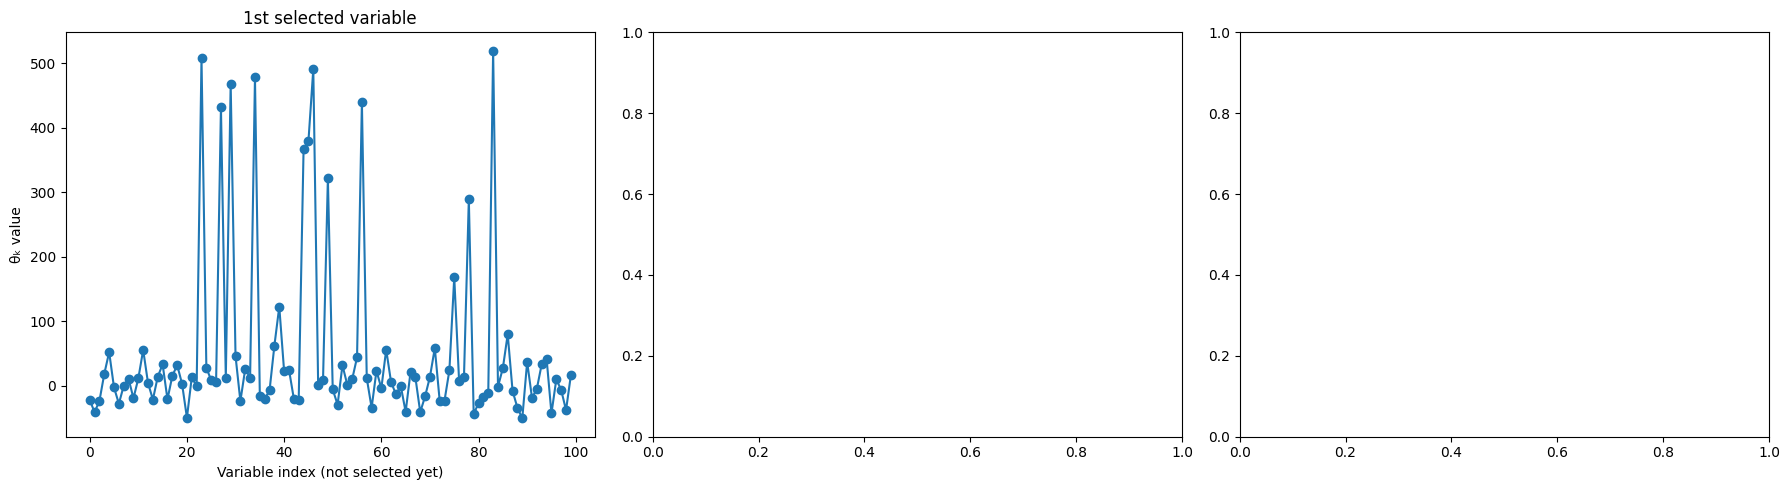

In [209]:
X = data2[names[:-1]].to_numpy()
y = data2[names[-1]].to_numpy()

V = y
not_selected = list(range(X.shape[1]))
selected_idx = []
p_vals = []
theta_first_sel = []
p_val = 0
while not_selected and p_val<0.05:
    theta_ks=  []
    for column in not_selected:
        X_k = X[:,column]
        theta_k =np.dot(X_k,V)/np.linalg.norm(X_k) # Statistic Test
        theta_ks.append(theta_k)
    sigma = np.std(theta_ks)
    theta_m = np.mean(theta_ks)
    p_val_thresh = np.percentile(theta_ks, 95)
    p_val = 2*np.sum((np.array(theta_ks)>p_val_thresh).astype(int))/len(theta_ks) # p-value
    p_vals.append(p_val)
    print(p_val)
    if len(selected_idx) < 3:
        theta_first_sel.append(theta_ks)
    best_idx = np.argmax(theta_ks)
    best_column = not_selected[best_idx]
    selected_idx.append(best_column)
    V = X[:, best_column]
    not_selected.remove(best_column)


fig, axs = plt.subplots(1, 3, figsize=(18, 5))
titles = ["1st selected variable", "2nd selected variable", "3rd selected variable"]

for i in range(len(theta_first_sel)):
    axs[i].plot(range(len(theta_first_sel[i])), theta_first_sel[i], marker='o')
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Variable index (not selected yet)")
    axs[i].set_ylabel("θₖ value")

plt.tight_layout()
plt.show()

- We find out that the algorithm stops in the first iteration, because ``p_val=0.1>0.05``


<Figure size 640x480 with 0 Axes>

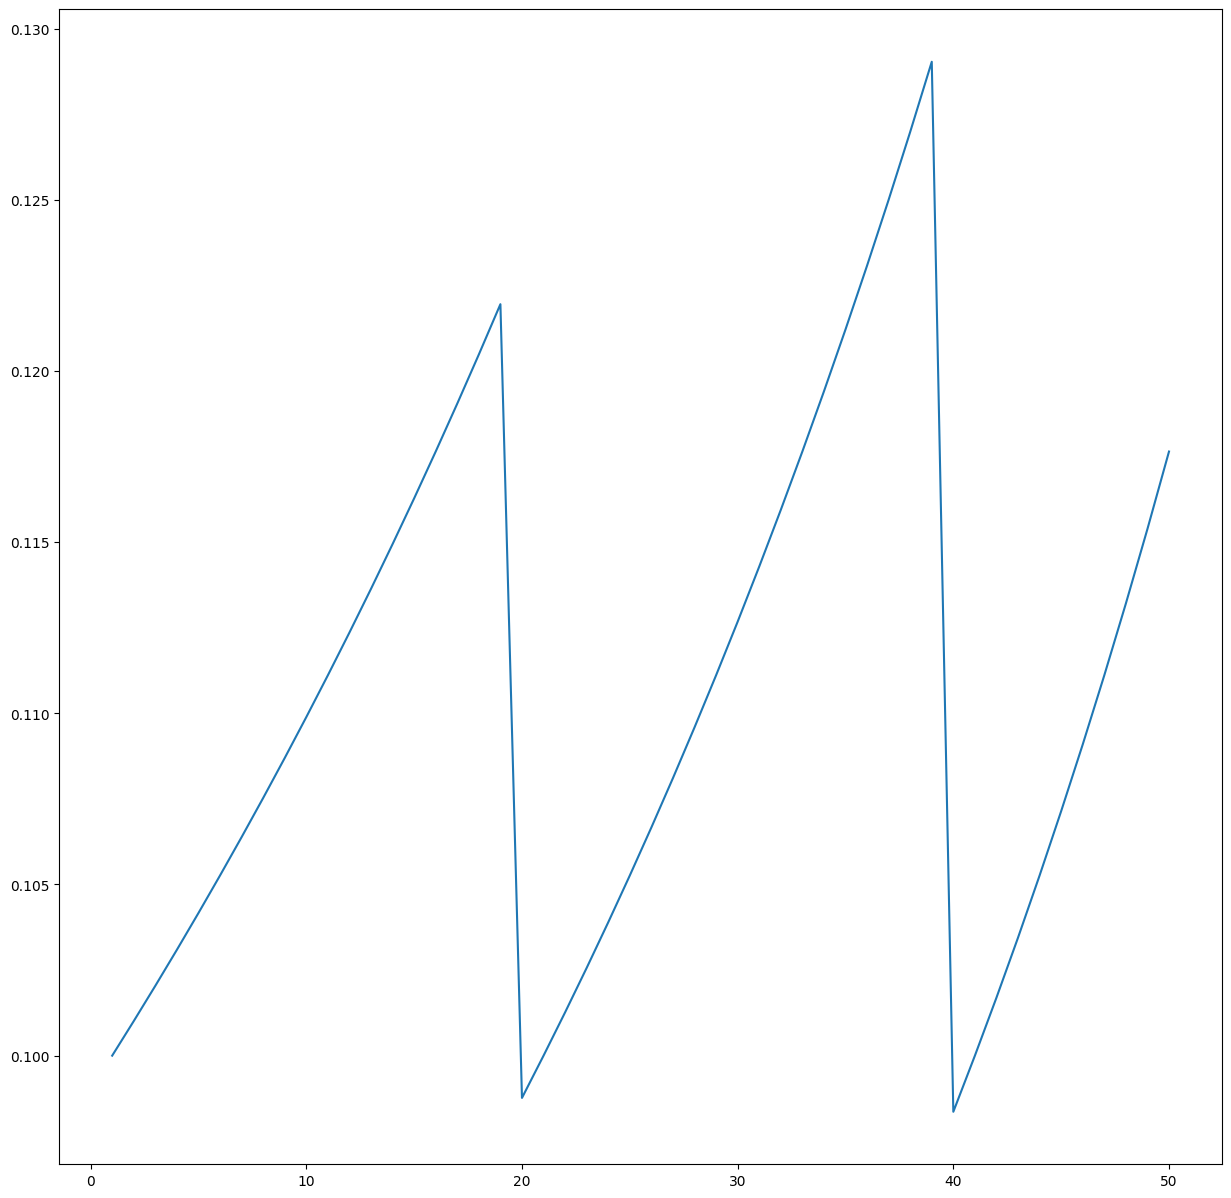

In [213]:
X = data2[names[:-1]].to_numpy()
y = data2[names[-1]].to_numpy()

V = y
not_selected = list(range(X.shape[1]))
selected_idx = []
p_vals = []
theta_first_sel = []
p_val = 0
while not_selected:
    theta_ks=  []
    for column in not_selected:
        X_k = X[:,column]
        theta_k =np.dot(X_k,V)/np.linalg.norm(X_k) # Statistic Test
        theta_ks.append(theta_k)
    sigma = np.std(theta_ks)
    theta_m = np.mean(theta_ks)
    p_val_thresh = np.percentile(theta_ks, 95)
    p_val = 2*np.sum((np.array(theta_ks)>p_val_thresh).astype(int))/len(theta_ks) # p-value
    p_vals.append(p_val)
    if len(selected_idx) < 3:
        theta_first_sel.append(theta_ks)
    best_idx = np.argmax(theta_ks)
    best_column = not_selected[best_idx]
    selected_idx.append(best_column)
    V = X[:, best_column]
    not_selected.remove(best_column)

plt.tight_layout()
plt.show()
plt.figure(figsize=(15,15))
plt.plot(range(1,51), p_vals[:50])

# Exercise 3
**Q13.**

In [215]:
names = ["X"+str(i) for i in range(1,21)]
names.append("y")
data3 = pd.read_csv("./datasets/data3.csv", header=None, names=names)
data3.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X12,X13,X14,X15,X16,X17,X18,X19,X20,y
0,2.139933,0.527973,1.049773,2.142699,1.346699,-1.037794,1.407544,-0.296160,-0.059760,-0.195398,...,0.722755,0.836302,0.521835,0.512542,0.107117,1.039134,-0.324901,0.245358,-0.822530,4.965032
1,-2.177109,0.781434,0.935471,-0.840359,1.748896,-1.514882,0.503215,-0.331986,1.576238,0.863362,...,-0.353356,-0.812521,-1.580636,-0.279233,-0.070209,0.775346,1.082637,-0.455037,-0.270737,5.015729
2,-0.672672,-1.292202,-1.635235,1.852581,-1.030511,-0.498590,-0.795339,0.632688,-1.570439,-0.818737,...,-0.344616,-0.435541,-0.780472,0.040497,0.201774,-0.388428,0.182729,-0.702032,-0.331176,-3.256408
3,-0.296580,-0.231738,-0.742111,-1.824477,-0.343433,-0.462297,-1.172742,0.317980,-0.863839,-0.554051,...,-0.602535,1.214665,-0.834666,0.471021,-0.911368,-1.325742,-0.698592,-0.379262,0.087731,-1.024643
4,-0.789269,1.028642,0.536698,-1.634438,0.967393,1.835373,1.636236,-0.324727,-1.027293,0.448455,...,0.490927,0.283539,1.376799,0.425046,0.480015,-0.444445,1.666128,0.059202,0.433555,-3.547037


In [217]:
X = data2[names[:-1]].to_numpy()
y = data2[names[-1]].to_numpy()

X_biased = np.hstack([np.ones((X_original.shape[0], 1)), X_original])
y = data1["y"].to_numpy()
xTx= np.dot(X.T, X)
theta_hat = np.dot(np.linalg.inv(xTx), np.dot(X.T, y))


lin_reg = linear_model.LinearRegression(fit_intercept=False)
lin_reg.fit(X, y)
coeffs = lin_reg.coef_

print(theta_hat)
print(coeffs)
print(f"Is both results the same ? Answer : {np.allclose(theta_hat,coeffs)}")



ValueError: shapes (20,506) and (50,) not aligned: 506 (dim 1) != 50 (dim 0)

The issue here is that $X^TX$ isn't invertible. So we can't compute the OLS.

**Q14.**

In [223]:
# Ridge 
X = data2[names[:-1]].to_numpy()
y = data2[names[-1]].to_numpy()
lambd=0.1

theta_hat_ridge = np.dot(np.linalg.inv(np.dot(X.T, X)+lambd*np.eye(X.shape[1])), np.dot(X.T,y))

lin_reg = linear_model.LinearRegression(fit_intercept=False)
lin_reg.fit(X, y)
coeffs = lin_reg.coef_
lasso = linear_model.Lasso(alpha=lambd, fit_intercept=False, max_iter=10000)
lasso.fit(X, y)
theta_hat_lasso = lasso.coef_


print(f"Is both results the same ? Answer : {np.allclose(theta_hat_ridge,coeffs)}, The diff (norm 2): {np.linalg.norm(theta_hat_ridge-coeffs)}")

print(f"Is both results the same ? Answer : {np.allclose(theta_hat_lasso,coeffs)}, The diff (norm 2): {np.linalg.norm(theta_hat_lasso-coeffs)}")


Is both results the same ? Answer : False, The diff (norm 2): 0.0032787714786317625
Is both results the same ? Answer : False, The diff (norm 2): 0.8789966422892881


The Ridge solution is very close to the scipy one, while the lasso one is further from the scipy one.
So the best method is the Ridge one.